In [1]:
import requests
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Buscando dados
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
params = {"vs_currency": "usd", "days": "365", "interval": "daily"}
dados = requests.get(url, params=params).json()

df = pd.DataFrame(dados["prices"], columns=["timestamp", "preco"])
df["data"] = pd.to_datetime(df["timestamp"], unit="ms")
df["retorno"] = df["preco"].pct_change()
df = df.dropna()

# Teste ADF — verifica se a série é estacionária
def teste_adf(serie, nome):
    resultado = adfuller(serie)
    p_valor = resultado[1]
    estacionaria = p_valor < 0.05
    print(f"=== {nome} ===")
    print(f"P-valor:      {p_valor:.6f}")
    print(f"Estacionária: {'SIM ✅' if estacionaria else 'NÃO ❌'}")
    print()

teste_adf(df["preco"], "Preço do BTC")
teste_adf(df["retorno"], "Retornos do BTC")

=== Preço do BTC ===
P-valor:      0.825206
Estacionária: NÃO ❌

=== Retornos do BTC ===
P-valor:      0.000000
Estacionária: SIM ✅



=== Relação BTC vs ETH ===
          data     preco_btc    preco_eth
359 2026-04-17  75149.193022  2348.704708
360 2026-04-18  77128.443349  2421.006954
361 2026-04-19  75728.456818  2350.936004
362 2026-04-20  73856.055015  2264.814399
363 2026-04-21  75874.546294  2315.024147


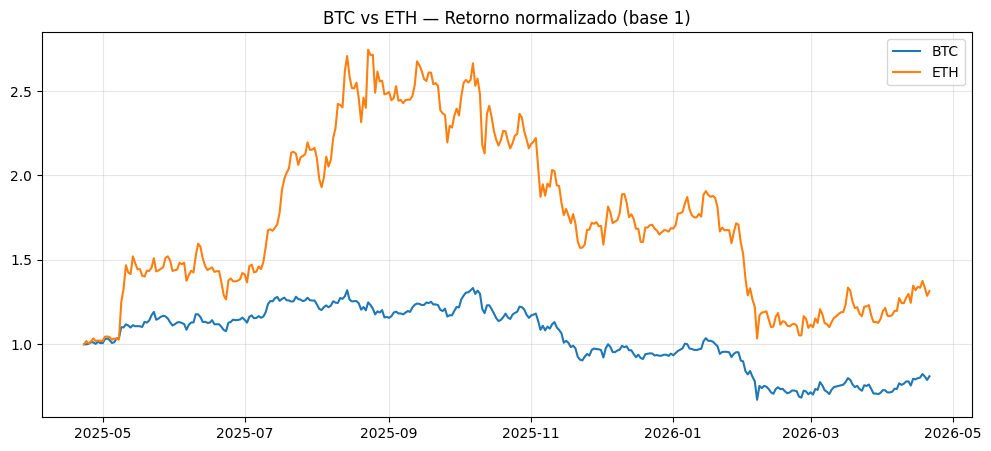

In [2]:
# Buscando ETH
url_eth = "https://api.coingecko.com/api/v3/coins/ethereum/market_chart"
params = {"vs_currency": "usd", "days": "365", "interval": "daily"}
dados_eth = requests.get(url_eth, params=params).json()

df_eth = pd.DataFrame(dados_eth["prices"], columns=["timestamp", "preco_eth"])
df_eth["data"] = pd.to_datetime(df_eth["timestamp"], unit="ms")

# Juntando BTC e ETH
df_par = df[["data", "preco"]].rename(columns={"preco": "preco_btc"})
df_par = df_par.merge(df_eth[["data", "preco_eth"]], on="data")

print("=== Relação BTC vs ETH ===")
print(df_par.tail(5))

# Plotando os dois normalizados
plt.figure(figsize=(12, 5))
plt.plot(df_par["data"], df_par["preco_btc"] / df_par["preco_btc"].iloc[0], label="BTC")
plt.plot(df_par["data"], df_par["preco_eth"] / df_par["preco_eth"].iloc[0], label="ETH")
plt.title("BTC vs ETH — Retorno normalizado (base 1)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

=== Teste de Cointegração BTC/ETH ===
P-valor:        0.829942
Cointegrados:   NÃO ❌

Ratio atual BTC/ETH: 32.77
Média 30 dias:       32.53
Z-score atual:       0.49


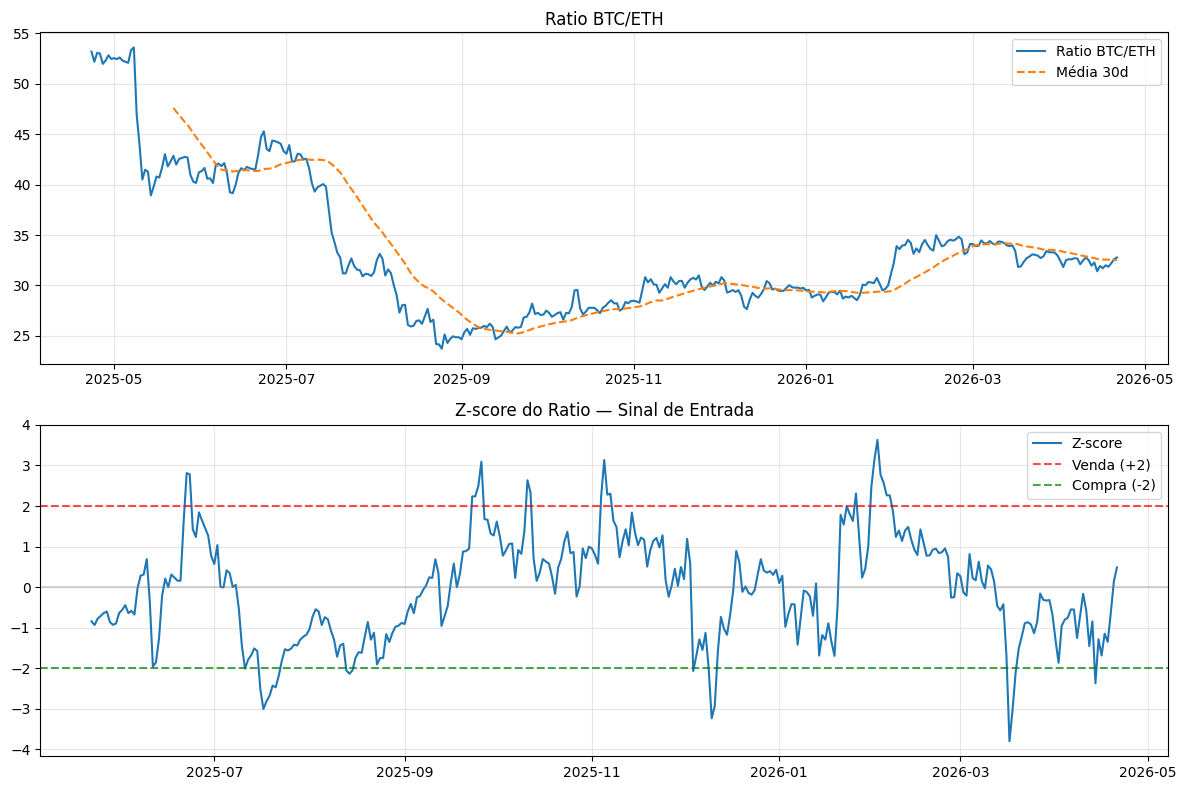

In [3]:
from statsmodels.tsa.stattools import coint

# Teste de cointegração
stat, p_valor, valores_criticos = coint(df_par["preco_btc"], df_par["preco_eth"])

print("=== Teste de Cointegração BTC/ETH ===")
print(f"P-valor:        {p_valor:.6f}")
print(f"Cointegrados:   {'SIM ✅' if p_valor < 0.05 else 'NÃO ❌'}")

# Calculando o spread entre os dois
df_par["ratio"] = df_par["preco_btc"] / df_par["preco_eth"]
df_par["ratio_media"] = df_par["ratio"].rolling(30).mean()
df_par["ratio_std"] = df_par["ratio"].rolling(30).std()
df_par["zscore"] = (df_par["ratio"] - df_par["ratio_media"]) / df_par["ratio_std"]

print(f"\nRatio atual BTC/ETH: {df_par['ratio'].iloc[-1]:.2f}")
print(f"Média 30 dias:       {df_par['ratio_media'].iloc[-1]:.2f}")
print(f"Z-score atual:       {df_par['zscore'].iloc[-1]:.2f}")

# Plotando
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(df_par["data"], df_par["ratio"], label="Ratio BTC/ETH")
axes[0].plot(df_par["data"], df_par["ratio_media"], label="Média 30d", linestyle="--")
axes[0].set_title("Ratio BTC/ETH")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df_par["data"], df_par["zscore"], label="Z-score")
axes[1].axhline(y=2, color="red", linestyle="--", alpha=0.7, label="Venda (+2)")
axes[1].axhline(y=-2, color="green", linestyle="--", alpha=0.7, label="Compra (-2)")
axes[1].axhline(y=0, color="gray", linestyle="-", alpha=0.3)
axes[1].set_title("Z-score do Ratio — Sinal de Entrada")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [4]:
# Buscando Solana para comparar com ETH
url_sol = "https://api.coingecko.com/api/v3/coins/solana/market_chart"
params = {"vs_currency": "usd", "days": "365", "interval": "daily"}
dados_sol = requests.get(url_sol, params=params).json()

df_sol = pd.DataFrame(dados_sol["prices"], columns=["timestamp", "preco_sol"])
df_sol["data"] = pd.to_datetime(df_sol["timestamp"], unit="ms")

df_par2 = df_eth[["data", "preco_eth"]].merge(df_sol[["data", "preco_sol"]], on="data")

# Testando cointegração ETH/SOL
stat2, p_valor2, _ = coint(df_par2["preco_eth"], df_par2["preco_sol"])

print("=== Teste de Cointegração ETH/SOL ===")
print(f"P-valor:      {p_valor2:.6f}")
print(f"Cointegrados: {'SIM ✅' if p_valor2 < 0.05 else 'NÃO ❌'}")

# Testando BTC/SOL também
df_par3 = df_par[["data", "preco_btc"]].merge(df_sol[["data", "preco_sol"]], on="data")
stat3, p_valor3, _ = coint(df_par3["preco_btc"], df_par3["preco_sol"])

print("\n=== Teste de Cointegração BTC/SOL ===")
print(f"P-valor:      {p_valor3:.6f}")
print(f"Cointegrados: {'SIM ✅' if p_valor3 < 0.05 else 'NÃO ❌'}")

# Resumo
print("\n=== Resumo dos Pares ===")
pares = {
    "BTC/ETH": p_valor,
    "ETH/SOL": p_valor2,
    "BTC/SOL": p_valor3
}
for par, pv in pares.items():
    status = "✅ Operar" if pv < 0.05 else "❌ Ignorar"
    print(f"{par}: p-valor={pv:.4f} → {status}")

=== Teste de Cointegração ETH/SOL ===
P-valor:      0.236273
Cointegrados: NÃO ❌

=== Teste de Cointegração BTC/SOL ===
P-valor:      0.539286
Cointegrados: NÃO ❌

=== Resumo dos Pares ===
BTC/ETH: p-valor=0.8299 → ❌ Ignorar
ETH/SOL: p-valor=0.2363 → ❌ Ignorar
BTC/SOL: p-valor=0.5393 → ❌ Ignorar


In [5]:
# Testando com janela menor — 180 dias
url_btc = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
url_eth = "https://api.coingecko.com/api/v3/coins/ethereum/market_chart"
url_sol = "https://api.coingecko.com/api/v3/coins/solana/market_chart"

params_180 = {"vs_currency": "usd", "days": "180", "interval": "daily"}

df_btc_180 = pd.DataFrame(
    requests.get(url_btc, params=params_180).json()["prices"],
    columns=["timestamp", "preco_btc"]
)
df_eth_180 = pd.DataFrame(
    requests.get(url_eth, params=params_180).json()["prices"],
    columns=["timestamp", "preco_eth"]
)
df_sol_180 = pd.DataFrame(
    requests.get(url_sol, params=params_180).json()["prices"],
    columns=["timestamp", "preco_sol"]
)

for df in [df_btc_180, df_eth_180, df_sol_180]:
    df["data"] = pd.to_datetime(df["timestamp"], unit="ms")

df_180 = df_btc_180[["data","preco_btc"]]\
    .merge(df_eth_180[["data","preco_eth"]], on="data")\
    .merge(df_sol_180[["data","preco_sol"]], on="data")

print("=== Cointegração — Janela 180 dias ===\n")
pares_180 = {
    "BTC/ETH": (df_180["preco_btc"], df_180["preco_eth"]),
    "ETH/SOL": (df_180["preco_eth"], df_180["preco_sol"]),
    "BTC/SOL": (df_180["preco_btc"], df_180["preco_sol"]),
}

for par, (s1, s2) in pares_180.items():
    _, pv, _ = coint(s1, s2)
    status = "✅ Operar" if pv < 0.05 else "❌ Ignorar"
    print(f"{par}: p-valor={pv:.4f} → {status}")

KeyError: 'prices'

In [ ]:
# Construindo o sinal de trading para BTC/ETH com janela 180 dias
df_180["ratio"] = df_180["preco_btc"] / df_180["preco_eth"]
df_180["ratio_media"] = df_180["ratio"].rolling(30).mean()
df_180["ratio_std"] = df_180["ratio"].rolling(30).std()
df_180["zscore"] = (df_180["ratio"] - df_180["ratio_media"]) / df_180["ratio_std"]

# Sinais de entrada e saída
# Z > +2: BTC caro em relação a ETH → vende BTC, compra ETH
# Z < -2: BTC barato em relação a ETH → compra BTC, vende ETH
# Z volta a 0: fecha posição
df_180["sinal"] = 0
df_180.loc[df_180["zscore"] > 2, "sinal"] = -1   # vende BTC
df_180.loc[df_180["zscore"] < -2, "sinal"] = 1    # compra BTC

total_sinais = (df_180["sinal"] != 0).sum()
zscore_atual = df_180["zscore"].iloc[-1]

print("=== Sinal BTC/ETH ===")
print(f"Z-score atual:    {zscore_atual:.2f}")
print(f"Total de sinais:  {total_sinais}")

if zscore_atual > 2:
    print("Sinal atual:      VENDE BTC / COMPRA ETH")
elif zscore_atual < -2:
    print("Sinal atual:      COMPRA BTC / VENDE ETH")
else:
    print("Sinal atual:      FORA DO MERCADO")

# Plotando
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(df_180["data"], df_180["ratio"], label="Ratio BTC/ETH")
axes[0].plot(df_180["data"], df_180["ratio_media"], label="Média 30d", linestyle="--")
axes[0].set_title("Ratio BTC/ETH — 180 dias")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df_180["data"], df_180["zscore"], label="Z-score")
axes[1].axhline(y=2, color="red", linestyle="--", alpha=0.7, label="Vende BTC (+2)")
axes[1].axhline(y=-2, color="green", linestyle="--", alpha=0.7, label="Compra BTC (-2)")
axes[1].axhline(y=0, color="gray", linestyle="-", alpha=0.3)
axes[1].fill_between(df_180["data"], df_180["zscore"],
    where=df_180["zscore"] > 2, alpha=0.2, color="red")
axes[1].fill_between(df_180["data"], df_180["zscore"],
    where=df_180["zscore"] < -2, alpha=0.2, color="green")
axes[1].set_title("Z-score — Zonas de entrada")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()